In [13]:
import json
import plotly.express as px
import pandas as pd
# import openpyxl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Tender schedule with starting point

In [26]:
with open('JSON/1 year/IC_F1_Qminimal.json') as json_file:
    F_results = json.load(json_file)


In [27]:

# List of keywords to search for
keywords_to_search = ["M"]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})


In [28]:
# List of keywords to search for
keywords_to_search2 = ["X", "F"]

# Initialize a dictionary to store grouped results
grouped_results2 = {keyword: [] for keyword in keywords_to_search2}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search2:
        if keyword in key:
            grouped_results2[keyword].append({key: value})

In [29]:
#filter for F and X, to show vaccines allocated per tender

# Extract the 'M' group
m_group = grouped_results.get('M', [])

# Filter dictionaries starting with 'X' or 'F' and exclude those with 'X_tilde'
filtered_dicts = [
    entry for entry in m_group
    if any((key.startswith(('X[', 'F')) and 'X_tilde' not in key) for key in entry)
       and not all(value == 0 for key, value in entry.items())
       and all('HPV' not in key for key in entry)
]

In [30]:
#filter for F and X, to show vaccines allocated per tender

# Extract the 'M' group
X_group = grouped_results2.get('X', [])

# Filter dictionaries starting with 'X' or 'F' and exclude those with 'X_tilde'
filtered_dicts2 = [
    entry for entry in X_group
    if any((key.startswith(('X[')) and 'X_tilde' not in key) for key in entry)
       and not all(value == 0 for key, value in entry.items())
       # and all('HPV' not in key for key in entry)
]

In [31]:
#group the data into X and F

# Function to group items by key start value
def group_by_start_value(items):
    grouped_data = {}

    for item in items:
        key = list(item.keys())[0]  # Extract the key from the dictionary
        start_value = key[0]  # Get the first character of the key
        if start_value not in grouped_data:
            grouped_data[start_value] = []
        grouped_data[start_value].append(item)

    return grouped_data

# Group the data
result = group_by_start_value(filtered_dicts)

result


{'F': [{'F[Measles,(6, 10)]': 1.0},
  {'F[Mumps,(2, 5)]': 1.0},
  {'F[Mumps,(6, 10)]': 1.0},
  {'F[Mumps,(1, 1)]': 1.0},
  {'F[Measles,(2, 5)]': 1.0},
  {'F[Mumps,(11, 15)]': 1.0},
  {'F[Measles,(1, 1)]': 1.0},
  {'F[Measles,(11, 15)]': 1.0}]}

In [32]:
#group the data into X and F

# Function to group items by key start value
def group_by_start_value(items):
    grouped_data = {}

    for item in items:
        key = list(item.keys())[0]  # Extract the key from the dictionary
        start_value = key[0]  # Get the first character of the key
        if start_value not in grouped_data:
            grouped_data[start_value] = []
        grouped_data[start_value].append(item)

    return grouped_data

# Group the data
result2 = group_by_start_value(filtered_dicts2)

result2

{'X': [{'X[Penta,Panacea_Biotec,7]': 4613113.207547166},
  {'X[HPV,Merck_Sharp,2]': 1699316.666666667},
  {'X[Rotavirus,Bharat_Biotech,5]': 13340004.729729734},
  {'X[Penta,Panacea_Biotec,3]': 4871792.452830186},
  {'X[Penta,Panacea_Biotec,11]': 4623891.50943396},
  {'X[OPV,Panacea_Biotec,14]': 16840816.627358492},
  {'X[PCV,Pfizer,1]': 3144265.0934034786},
  {'X[HPV,Merck_Sharp,12]': 3097141.6666666665},
  {'X[Rotavirus,Bharat_Biotech,15]': 13393762.35219595},
  {'X[OPV,Panacea_Biotec,9]': 16786886.792452835},
  {'X[PCV,Pfizer,5]': 4361852.418746792},
  {'X[HPV,Merck_Sharp,14]': 3090289.5833333335},
  {'X[PCV,Pfizer,12]': 4339069.686524454},
  {'X[OPV,Panacea_Biotec,5]': 17022216.98113208},
  {'X[PCV,Pfizer,15]': 4333982.182764137},
  {'X[Penta,Panacea_Biotec,5]': 4677783.018867922},
  {'X[Rotavirus,Bharat_Biotech,1]': 12715676.47058824},
  {'X[Penta,Panacea_Biotec,14]': 4627933.372641507},
  {'X[PCV,Pfizer,10]': 4352635.467359288},
  {'X[HPV,Merck_Sharp,8]': 3782350.000000001},
  {'X

In [22]:
# create dictionary from F data from above
# Extracting information from the dictionary
data_list = []
for item in result['F']:
    key, value = list(item.items())[0]
    # print(key)
    tender = key.split('[', 1)[1].split(',', 1)[0]
    start, finish = eval(key.split('(', 1)[1].split(')', 1)[0])
    value = item[key]
    
    data_list.append({'Tender': tender, 'Start': start, 'Finish': finish, 'Value': value})

# Create a DataFrame
F_values_df = pd.DataFrame(data_list)
F_values_df = F_values_df[F_values_df.Tender == 'Measles']
F_values_df.Start = F_values_df.Start -1
# Display the DataFrame
F_values_df


,Tender,Start,Finish,Value
0,Measles,5,10,1.0
4,Measles,1,5,1.0
6,Measles,0,1,1.0
7,Measles,10,15,1.0


In [25]:

# Extracting data for the DataFrame
df_data = []
for entry in result['M']:
    key, value = entry.popitem()
    vaccine = key.split(',')[0][2:]
    producer = key.split(',')[1].strip()
    start = int(key.split(',')[2].split(']')[0])
    end = int(start)
    df_data.append({'Vaccine': vaccine, 'Producer': producer, 'Start': start, 'End': end, 'Value': value})

# Creating DataFrame
X_data = pd.DataFrame(df_data)

# Print the DataFrame
X_data.head()


KeyError: 'M'

In [33]:

# Extracting data for the DataFrame
df2_data = []
for entry in result2['X']:
    key, value = entry.popitem()
    vaccine = key.split(',')[0][2:]
    producer = key.split(',')[1].strip()
    start = int(key.split(',')[2].split(']')[0])
    end = int(start)
    df2_data.append({'Vaccine': vaccine, 'Producer': producer, 'Start': start, 'End': end, 'Value': value})

# Creating DataFrame
X_data_penta = pd.DataFrame(df2_data)

Vaccines_to_keep = ['Penta','TT', 'Td', 'DT','DTwP','HepB', 'DTwP-Hib', 'OPV', 'IPV']
X_data_penta = X_data_penta[X_data_penta['Vaccine'].isin(Vaccines_to_keep)]

# Print the DataFrame
X_data_penta


,Vaccine,Producer,Start,End,Value
0,Penta,Panacea_Biotec,7,7,4.613113e+06
3,Penta,Panacea_Biotec,3,3,4.871792e+06
4,Penta,Panacea_Biotec,11,11,4.623892e+06
5,OPV,Panacea_Biotec,14,14,1.684082e+07
9,OPV,Panacea_Biotec,9,9,1.678689e+07
13,OPV,Panacea_Biotec,5,5,1.702222e+07
15,Penta,Panacea_Biotec,5,5,4.677783e+06
17,Penta,Panacea_Biotec,14,14,4.627933e+06
22,Penta,Panacea_Biotec,13,13,4.626586e+06
23,Penta,Panacea_Biotec,6,6,4.548443e+06


In [34]:
X_data_penta.Producer.unique()


array(['Panacea_Biotec'], dtype=object)

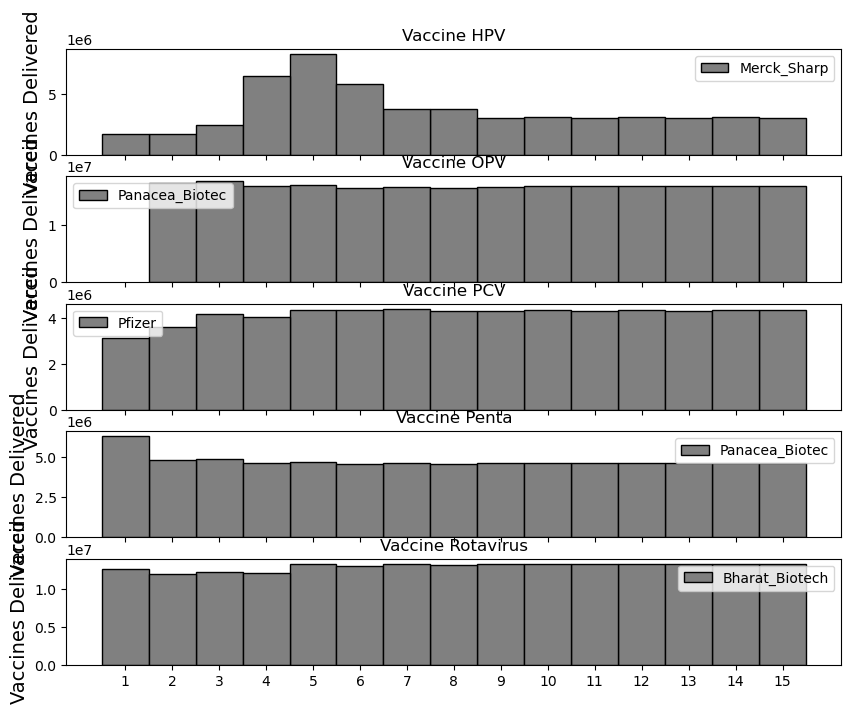

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Using DataFrame.insert() to add a column
# F_values_df.insert(2, "Color", ['green', 'blue', 'orange', 'red', 'grey', 'purple','yellow','maroon'], True)

# Create subplots for each vaccine
fig, axs = plt.subplots(nrows=len(X_data['Vaccine'].unique()), figsize=(10, 8), sharex=True)

# Define unique colors for each producer
producer_colors = {'Biological_E': 'blue', 'Serum_Institute': 'orange', 'PT_Bio': 'green', 'GSK': 'red', 'Merck_Sharp':'grey'}

# Plot stacked bars for each vaccine
for i, (vaccine, group) in enumerate(X_data.groupby('Vaccine')):
    producers = group['Producer'].unique()
    
    for producer in producers:
        producer_data = group[group['Producer'] == producer]
        axs[i].bar(producer_data['Start'], producer_data['Value'], label=producer, bottom=np.zeros(len(producer_data)), width=1.0, edgecolor='black', linewidth=1, color=producer_colors.get(producer, 'gray'))

    axs[i].set_title(f'Vaccine {vaccine}')
    axs[i].set_ylabel('Vaccines Delivered', fontsize=14)
    axs[i].legend()
    


# Set x-axis ticks for each year
for ax in axs.flat:
    ax.set_xticks(np.arange(min(X_data['Start']), max(X_data['End']) + 1, 1))
    # ax.set_xlabel('Time (Start)')


# plt.suptitle('Measles vaccination by Vaccine/Producer')
plt.savefig('Deterministic_results_F_Q_I_S_30_with_mod_MMR.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


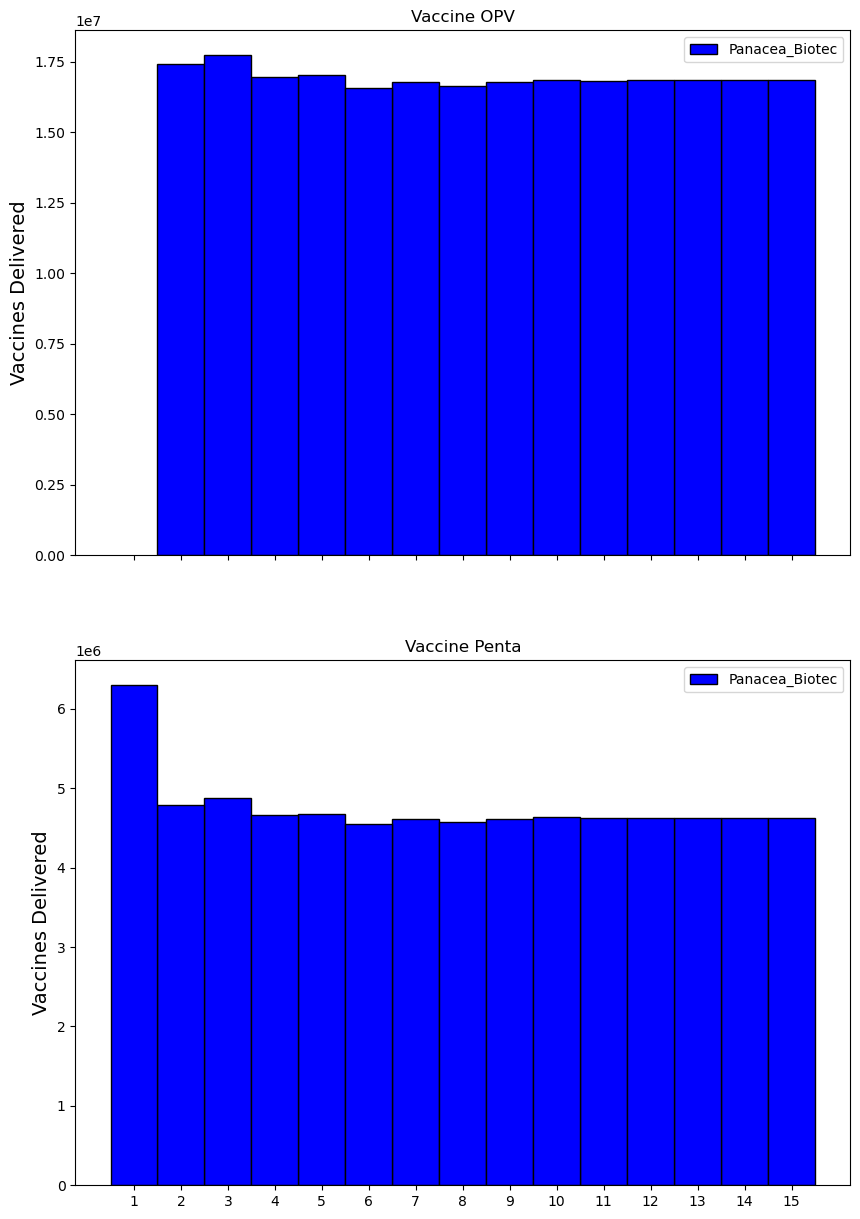

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Using DataFrame.insert() to add a column
# F_values_df.insert(2, "Color", ['green', 'blue', 'orange', 'red', 'grey', 'purple','yellow','maroon'], True)

# Create subplots for each vaccine
fig, axs = plt.subplots(nrows=len(X_data_penta['Vaccine'].unique()), figsize=(10, 15), sharex=True)

# Define unique colors for each producer
producer_colors = {'Panacea_Biotec': 'blue', 'Serum_Institute': 'orange',
                   'PT_Bio': 'green', 'Haffkine_Bio': 'yellow', 'Bharat_Biotech':'cyan',
                   'LG_Chem': 'red', 'BB_NCIPD':'grey', 'Biological_E':'maroon'}

# Plot stacked bars for each vaccine
for i, (vaccine, group) in enumerate(X_data_penta.groupby('Vaccine')):
    producers = group['Producer'].unique()
    
    for producer in producers:
        producer_data = group[group['Producer'] == producer]
        axs[i].bar(producer_data['Start'], producer_data['Value'], label=producer, bottom=np.zeros(len(producer_data)), width=1.0, edgecolor='black', linewidth=1, color=producer_colors.get(producer, 'gray'))

    axs[i].set_title(f'Vaccine {vaccine}')
    axs[i].set_ylabel('Vaccines Delivered', fontsize=14)
    axs[i].legend()
    


# Set x-axis ticks for each year
for ax in axs.flat:
    ax.set_xticks(np.arange(min(X_data_penta['Start']), max(X_data_penta['End']) + 1, 1))
    # ax.set_xlabel('Time (Start)')


# plt.suptitle('Measles vaccination by Vaccine/Producer')
plt.savefig('Deterministic_results_F_Q_I_S_30_with_mod_Penta.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

In [68]:
# X_data = X_data[X_data.Vaccine == "MMR"].copy()
# X_data.to_csv('MR_data2.csv', index=False)

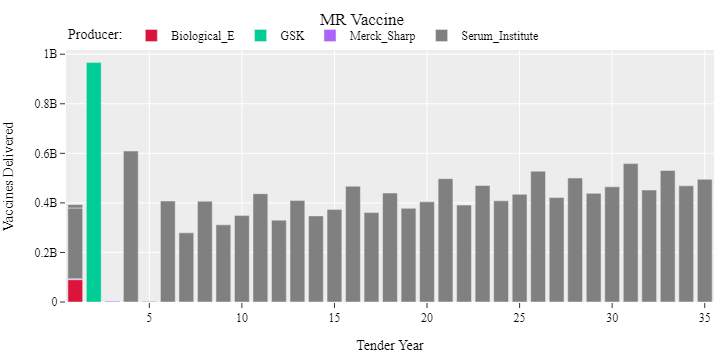

In [69]:
X_data.sort_values(by=["Producer"], inplace=True)
fig = px.bar(X_data, x="Start", y="Value", color="Producer", title="MR Vaccine", color_discrete_map={"Serum_Institute": "grey", "Biological_E": "crimson"},)
fig.update_layout(
    font=dict(family="CMU Serif", size=12, color="black"),
    margin=dict(l=50, r=10, b=50, t=50, pad=0),
    template="ggplot2",
    height=300,
    width=800,
    xaxis=dict(title="Tender Year"),
    yaxis=dict(title="Vaccines Delivered"),
    legend=dict(title="Producer:", orientation="h", yanchor="bottom", x=0, y=1.0, xanchor="left"),
)
fig.show()

fig.write_image("MR_data.png", scale=4)